In [1]:
!pip install -q selenium
!pip install -q webdriver-manager
!pip install -q beautifulsoup4 fake-useragent pandas tqdm requests

!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt-get install -y -q ./google-chrome-stable_current_amd64.deb
!rm google-chrome-stable_current_amd64.deb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 5.5 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas libatk-bridge2.0-0 libatk1.0-0
  libatk1.0-data libatspi2.0-0 libvulkan1 libxcomposite1 libxtst6
  mesa-vulkan-drivers session-migration
The following NEW packages will be installed:
  at-spi2-core google-chrome-stable gsettings-desktop-schemas
  libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0 libvulkan1
  libxcomposite1 libxtst6 mesa-vulkan-drivers session-migration
0 upgraded, 12 newly installed, 0 to remove and 2 not upgraded.
Need to get 11.2 MB/136 MB of archives.
After this operation

In [2]:
import requests
import pandas as pd
import re
from bs4 import BeautifulSoup
from tqdm import tqdm
from time import sleep
import json
import logging
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

In [3]:
config = {
    "logging_enabled": True,
    "log_level": "INFO",
    "log_file": "scraper.log"
}

In [4]:
if config['logging_enabled']:
  logging.basicConfig(
      level=getattr(logging, config['log_level'].upper(), logging.INFO),
      filename=config['log_file'],
      format='%(asctime)s - %(levelname)s - %(funcName)s - %(message)s',
      force=True,
      datefmt='%H:%M:%S')
  logging.info('Логирование включено')

In [5]:
options = Options()
options.binary_location = '/usr/bin/google-chrome'
options.add_argument('--headless=new')
options.add_argument('--no-sandbox')
options.add_argument('--disable-dev-shm-usage')
options.add_argument('--disable-gpu')

service = Service(ChromeDriverManager().install())
browser = webdriver.Chrome(service=service, options=options)
logging.info('Selenium browser успешно создан')

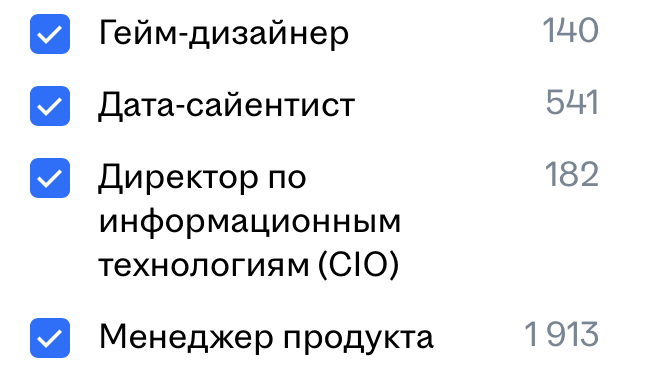

In [6]:
url_hh2 = 'https://hh.ru/search/vacancy?area=113&L_save_area=true&search_field=name&search_field=company_name&search_field=description&enable_snippets=true&professional_role=25&professional_role=165&professional_role=36&professional_role=73'
page = requests.get(url_hh2)
browser.get(url_hh2)
sleep(3)
html = browser.page_source
soup = BeautifulSoup(html, 'html.parser')
browser.title
logging.info(f'Страница открывается: {url_hh2}')
def get_page(p):
  url = f'{url_hh2}&page={p}'
  browser.get(url)
  sleep(3)
  logging.info(f'Открыта страница с ваканиями: {url}')
  soup = BeautifulSoup(browser.page_source, 'html.parser')

  urls = []

  for link in soup.find_all('a'):
    if link.get('href') is not None and 'hh.ru/vacancy/' in link.get('href'):
      href = link.get('href').split('?')[0]
      urls.append(href)
  urls = list(set(urls))
  logging.info(f'На странице {p} найдено {len(urls)} уникальных ссылок')
  return urls
def GetVacancy(url0):
  browser.get(url0)
  sleep(3)
  soup0 = BeautifulSoup(browser.page_source, 'html.parser')

  try:
    title = soup0.find('h1')
    title = title.get_text(strip=True)
  except AttributeError:
    title = None

  try:
    company = soup0.find(attrs={'data-qa': 'vacancy-company-name'})
    company = company.get_text(strip=True)
  except AttributeError:
    company = None

  try:
    salary = soup0.find(attrs={'data-qa': 'vacancy-salary'})
    salary = salary.get_text(' ', strip=True)
  except AttributeError:
    salary = None

  try:
    experience = soup0.find(attrs={'data-qa': 'vacancy-experience'})
    experience = experience.get_text(strip=True)
  except AttributeError:
    experience = None

  try:
    location = soup0.find(attrs={'data-qa': 'vacancy-view-location'})
    location = location.get_text(' ', strip=True)
  except AttributeError:
    location = None

  try:
    description = soup0.find(attrs={'data-qa': 'vacancy-description'})
    description = description.get_text(' ', strip=True)
  except AttributeError:
    description = None

  try:
    date = soup0.find('meta', {'property': 'article:published_time'}).get('content')
  except AttributeError:
    date = None

  try:
    tags_raw = soup0.find('ul', class_='vacancy-skill-list--JsTYRZ5o6dsoavK7')
    tags_raw = tags_raw.get_text(', ', strip=True)
  except AttributeError:
    tags_raw = None

  result = {
      'url': url0,
      'title': title,
      'date': date,
      'company': company,
      'salary': salary,
      'experience': experience,
      'location': location,
      'tags_raw': tags_raw,
      'description': description,
      'source': 'hh_ru'}
  logging.info(f'Вакансия {title} спарсена')
  return result

In [7]:
infa = []

for p in tqdm(range(0,40)):
  try:
    infa.extend(get_page(p))
    sleep(5)
  except:
    print(p)
    logging.exception(f'Ошибка при обработке страницы {p}')
logging.info(f'Всего собрано {len(infa)} ссылок')

100%|██████████| 40/40 [09:13<00:00, 13.83s/it]


In [8]:
vacancies_hh = []

for link in tqdm(infa):
  try:
    print(link)
    res = GetVacancy(link)
    vacancies_hh.append(res)
    sleep(5)
  except:
    print(link)
    logging.exception(f'Ошибка при парсинге вакансии {link}')
logging.info(f'Всего спарсено {len(vacancies_hh)} вакансий')

  0%|          | 0/2000 [00:00<?, ?it/s]

https://hh.ru/vacancy/131672943


  0%|          | 1/2000 [00:12<6:46:46, 12.21s/it]

https://hh.ru/vacancy/131577825


  0%|          | 2/2000 [00:24<6:49:39, 12.30s/it]

...

100%|█████████▉| 1998/2000 [6:25:24<00:22, 11.36s/it]

https://hh.ru/vacancy/131985999


100%|█████████▉| 1999/2000 [6:25:36<00:11, 11.59s/it]

https://hh.ru/vacancy/131548114


100%|██████████| 2000/2000 [6:25:48<00:00, 11.57s/it]


In [10]:
df = pd.DataFrame(vacancies_hh)
df.head(2)
logging.info(f'Таблица вакансий hh2 создана')
df.to_csv('hh2.csv')
logging.info(f'Файл hh2 загружен')

In [11]:
browser.quit()
logging.info(f'Browser закрыт')